<a href="https://colab.research.google.com/github/ghanshyamverma4654/Mission-Data-Science/blob/master-branch/GoogleTrendsAnalysis_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pytrends

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pytrends.request import TrendReq
from warnings import filterwarnings
filterwarnings('ignore')

**Setting up pytrends library and keyword definition**

In [ ]:
pytrends = TrendReq(hl='en-US', tz=360)
keyword = 'AI'

**Q1: Write a code where, by changing just the keyword, we can search for multiple thing.**

In [ ]:
pytrends.build_payload([keyword], cat=0, timeframe='today 12-m', geo='', gprop='')

**Q2: Top 15 countries where the keywords are searched the most, and also create visual representation of it.**

Text(0, 0.5, 'Country')

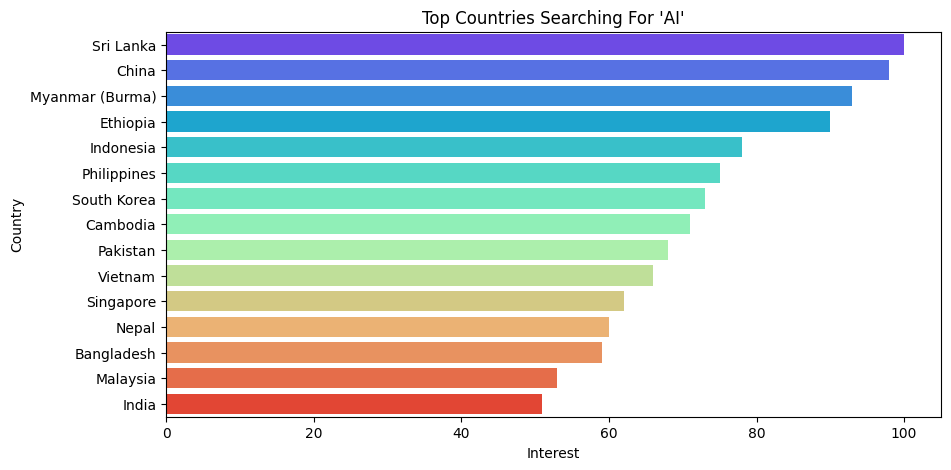

In [ ]:
region_data = pytrends.interest_by_region()
region_data = region_data.sort_values(by=keyword, ascending=False)
region_data = region_data.head(15)
#region_data

plt.figure(figsize=(10, 5))
sns.barplot(data = region_data, y=region_data.index, x = keyword, palette = 'rainbow')
plt.title(f"Top Countries Searching For '{keyword}'")
plt.xlabel('Interest')
plt.ylabel('Country')

**Q3: A world map needs to be plotted showing the countries that search the keyword the most.**

In [ ]:
region_data = region_data.reset_index()
fig = px.choropleth(region_data,
                    locations='geoName',
                    locationmode='country names',
                    color=keyword,
                    title=f"Search Interest in Countries for '{keyword}'",
                    color_continuous_scale='rainbow'
                    )
fig.show()

**Q4: We need to extract the time-wise interest of the keyword - how it trended in different years.**

In [ ]:
trend_data = pytrends.interest_over_time()
#trend_data

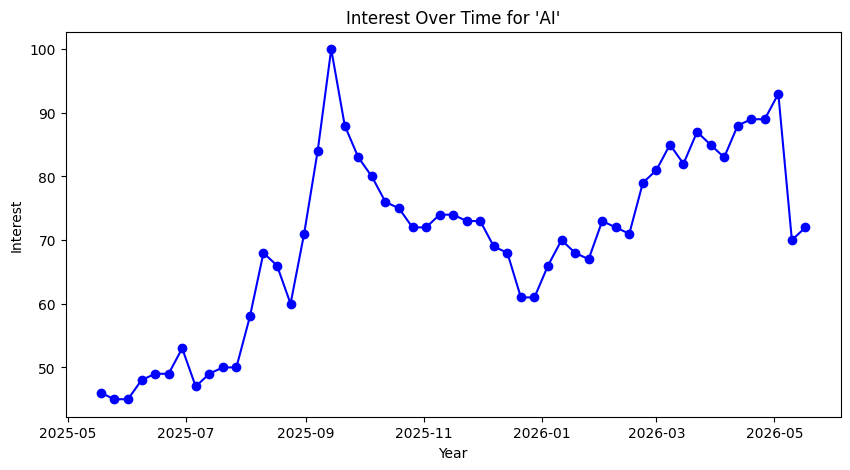

In [ ]:
plt.figure(figsize = (10,5))
plt.plot(trend_data.index, trend_data[keyword], marker = 'o', color = 'blue')
plt.title(f"Interest Over Time for '{keyword}'")
plt.xlabel('Year')
plt.ylabel('Interest')
plt.show()

**Q5: Compare related keywords and plot the graph.**

In [ ]:
#Creating list for multiple keywords
kw_list = ['Artificial Intelligence','Machine learning','data science','Chat gpt', 'claude AI']

pytrends.build_payload(kw_list, cat=0, timeframe='today 12-m', geo='',gprop='')

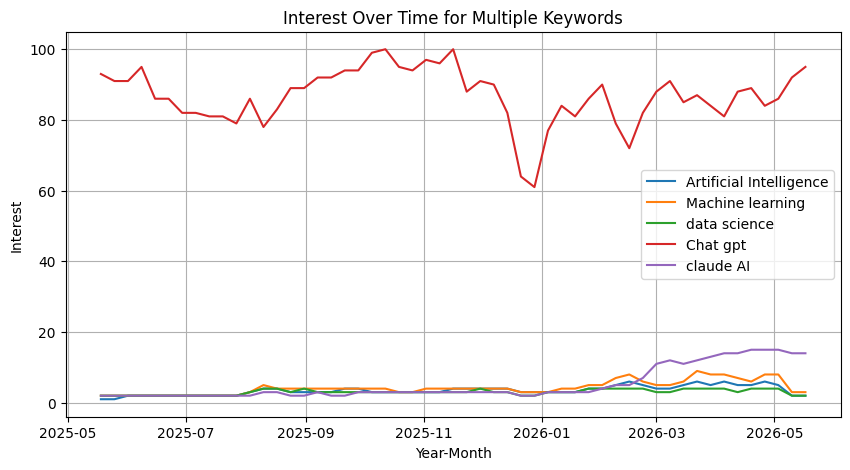

In [ ]:
compare_data = pytrends.interest_over_time()

plt.figure(figsize = (10,5))
for keyword in kw_list:
    plt.plot(compare_data.index, compare_data[keyword],label = keyword)
plt.title("Interest Over Time for Multiple Keywords")
plt.xlabel('Year-Month')
plt.ylabel('Interest')
plt.legend()
plt.grid(True)
plt.show()
